# VAE

In [94]:
%reload_ext watermark
%watermark -a 'Yasir Awais Butt' -v -p torch

Author: Yasir Awais Butt

Python implementation: CPython
Python version       : 3.12.3
IPython version      : 9.13.0

torch: 2.11.0+cu128



# Imports

In [95]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [96]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
# Hyperparameters
BATCH_SIZE = 256
LEARNING_RATE = 0.0005
EPOCHS = 50
LATENT_DIM = 2
RANDOM_SEED = 42
# Load MNIST dataset
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root = "../../data",
                               train = True,
                               transform = transform,
                               download = True)
test_dataset = datasets.MNIST(root = "../../data",
                              train = False,
                              transform = transform,
                              download = True)
test_loader = DataLoader(test_dataset, 
                         batch_size = BATCH_SIZE, 
                         shuffle = False)
train_loader = DataLoader(train_dataset, 
                          batch_size = BATCH_SIZE, 
                          num_workers = 2,
                          shuffle = True)

Using device: cuda


In [97]:
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
for images, labels in train_loader:
    print(f"Batch of images shape: {images.shape}")
    print(f"Batch of labels shape: {labels.shape}")
    break


Number of training samples: 60000
Number of test samples: 10000
Batch of images shape: torch.Size([256, 1, 28, 28])
Batch of labels shape: torch.Size([256])


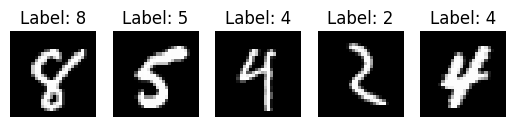

In [98]:
for i in range(5):
    images, labels = next(iter(train_loader))
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[0].squeeze(), cmap = "gray")
    plt.title(f"Label: {labels[0].item()}")
    plt.axis("off")
plt.show()

In [99]:
print(f"Number of testing samples: {len(test_dataset)}")
for images, labels in test_loader:
    print(f"Batch of images shape: {images.shape}")
    print(f"Batch of labels shape: {labels.shape}")
    break

Number of testing samples: 10000
Batch of images shape: torch.Size([256, 1, 28, 28])
Batch of labels shape: torch.Size([256])


In [100]:
import numpy as np
import random

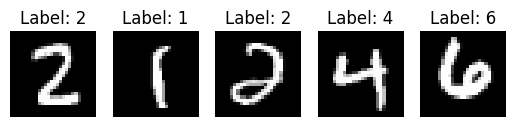

In [101]:
for i in range(5):
    idx = random.randrange(len(test_dataset))
    images, labels = test_dataset[idx]
    plt.subplot(1, 5, i+1)
    plt.imshow(images[0].squeeze(), cmap = "gray")
    plt.title(f"Label: {labels}")
    plt.axis("off")
plt.show()

# Model

In [102]:
class Reshape(nn.Module):
    def __init__(self, *args):
        super(Reshape, self).__init__()
        self.shape = args

    def forward(self, x):
        return x.view(self.shape)
class Trim(nn.Module):
    def __init__(self, *args):
        super().__init__()
        self.shape = args

    def forward(self, x):
        return x[:, :, :28, :28]

In [103]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim 
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size = 3, stride = 1, padding = 1),  # (B, 32, 28, 28)
            nn.LeakyReLU(0.01),
            nn.Conv2d(32, 64, kernel_size = 3, stride = 2, padding = 1), # (B, 64, 14, 14)
            nn.LeakyReLU(0.01),
            nn.Conv2d(64, 64, kernel_size = 3, stride = 2, padding = 1), # (B, 64, 7, 7)
            nn.LeakyReLU(0.01),
            nn.Conv2d(64, 64, kernel_size = 3, stride = 1, padding = 1), # (B, 64, 7, 7)
            nn.Flatten()
        )
        self.z_mean = nn.Linear(64 * 7 * 7, latent_dim)
        self.z_log_var = nn.Linear(64 * 7 * 7, latent_dim)
        #Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64 * 7 * 7),
            Reshape(-1, 64, 7, 7),
            nn.ConvTranspose2d(64, 64, kernel_size = 3, stride = 1, padding = 1), # (B, 64, 7, 7)
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(64, 64, kernel_size = 3, stride = 2, padding = 1, output_padding = 1), # (B, 64, 14, 14)
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(64, 32, kernel_size = 3, stride = 2, padding = 1, output_padding = 1), # (B, 32, 28, 28)
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(32, 1, kernel_size = 3, stride = 1, padding = 1), # (B, 1, 28, 28)
            Trim(),
            nn.Sigmoid()
        )
    def encoding_fn(self, x):
        h = self.encoder(x)
        z_mean = self.z_mean(h)
        z_log_var = self.z_log_var(h)
        encoded = self.reparametrize(z_mean, z_log_var)
        return encoded
    def reparametrize(self, z_mean, z_log_var):
        eps = torch.randn(z_mean.size(0), z_mean.size(1)).to(DEVICE)
        z = z_mean + eps*torch.exp(z_log_var / 2)
        return z
    def forward(self, x):
        z_mean, z_log_var = self.z_mean(self.encoder(x)), self.z_log_var(self.encoder(x))
        encoded = self.reparametrize(z_mean, z_log_var)
        decoded = self.decoder(encoded)
        return encoded, decoded, z_mean, z_log_var
    

In [104]:
from helper_utils import set_all_seeds
import time
set_all_seeds(RANDOM_SEED)

In [105]:
model = VAE(latent_dim = LATENT_DIM).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr = LEARNING_RATE)
criterion = nn.MSELoss()

In [106]:
def train_vae_v1(num_epochs, model, optimizer, device,
                 train_loader, loss_fn = None,
                 logging_interval = 100,
                 skip_epoch_stats = False,
                 reconstruction_term_weight = 1,
                 save_model = None):
        log_dict = {'train_combined_loss_per_batch': [],
                    'train_combined_loss_per_epoch': [],
                    'train_reconstruction_loss_per_batch': [],
                    'train_kl_loss_per_batch': []}
        if loss_fn is None:
            loss_fn = nn.MSELoss()
        start_time = time.time()
        for epoch in range(num_epochs):
            epoch_start_time = time.time()
            model.train()
            for batch_idx, (images, _) in enumerate(train_loader):
                images = images.to(device)
                optimizer.zero_grad()
                encoded, decoded, z_mean, z_log_var = model(images)
                P = decoded[0].numel()
                reconstruction_loss = loss_fn(decoded, images)*784
                kl_loss = -0.5 * torch.sum(1 + z_log_var - z_mean.pow(2) - z_log_var.exp(),
                                           axis = 1).mean()
                combined_loss = reconstruction_term_weight * reconstruction_loss + kl_loss
                combined_loss.backward()
                optimizer.step()
                log_dict['train_combined_loss_per_batch'].append(combined_loss.item())
                log_dict['train_reconstruction_loss_per_batch'].append(reconstruction_loss.item())
                log_dict['train_kl_loss_per_batch'].append(kl_loss.item())
                if batch_idx % logging_interval == 0:
                    print(f"Epoch [{epoch+1:02d}/{num_epochs:02d}] | Batch [{batch_idx:03d}/{len(train_loader):03d}] |"
                          f"Combined Loss: {combined_loss.item():.4f} ")
                          #f"Reconstruction Loss: {reconstruction_loss.item():.4f} "
                          #f"KL Loss: {kl_loss.item():.4f}")
            epoch_end_time = time.time()
            epoch_duration = epoch_end_time - epoch_start_time
            if not skip_epoch_stats:
                avg_combined_loss = np.mean(log_dict['train_combined_loss_per_batch'][-len(train_loader):])
                log_dict['train_combined_loss_per_epoch'].append(avg_combined_loss)
                print(f"Epoch [{epoch+1:03d}/{num_epochs:03d}] completed in {epoch_duration:.2f} seconds. "
                      f"Average Combined Loss: {avg_combined_loss:.4f}")
        total_training_time = time.time() - start_time
        print(f"Training completed in {total_training_time:.2f} seconds.")
        if save_model is not None:
            torch.save(model.state_dict(), save_model)
            print(f"Model saved to {save_model}")
        return log_dict

In [107]:
train_log = train_vae_v1(num_epochs = EPOCHS,
                         model = model,
                         optimizer = optimizer,
                         device = DEVICE,
                         train_loader = train_loader,
                         loss_fn = criterion,
                         logging_interval = 100,
                         skip_epoch_stats = False,
                         reconstruction_term_weight = 1,
                         save_model = "vae_mnist.pth")

Epoch [01/50] | Batch [000/235] |Combined Loss: 184.6334 
Epoch [01/50] | Batch [100/235] |Combined Loss: 51.1897 
Epoch [01/50] | Batch [200/235] |Combined Loss: 46.6155 
Epoch [001/050] completed in 3.84 seconds. Average Combined Loss: 60.0331
Epoch [02/50] | Batch [000/235] |Combined Loss: 44.7453 
Epoch [02/50] | Batch [100/235] |Combined Loss: 42.3795 
Epoch [02/50] | Batch [200/235] |Combined Loss: 40.8941 
Epoch [002/050] completed in 3.79 seconds. Average Combined Loss: 43.1606
Epoch [03/50] | Batch [000/235] |Combined Loss: 42.5963 
Epoch [03/50] | Batch [100/235] |Combined Loss: 41.5750 
Epoch [03/50] | Batch [200/235] |Combined Loss: 42.4581 
Epoch [003/050] completed in 3.87 seconds. Average Combined Loss: 41.6874
Epoch [04/50] | Batch [000/235] |Combined Loss: 39.8812 
Epoch [04/50] | Batch [100/235] |Combined Loss: 39.0205 
Epoch [04/50] | Batch [200/235] |Combined Loss: 41.4817 
Epoch [004/050] completed in 3.91 seconds. Average Combined Loss: 40.9458
Epoch [05/50] | Bat

In [108]:
def plot_training_data(loss, num_epochs, averaging_iterations = 100, custom_label = ''):
    iter_per_epoch = len(loss) // num_epochs
    plt.figure(figsize = (12, 6))
    ax1 = plt.subplot(1,1,1)
    ax1.plot(range(len(loss)), loss, label = f"Minibatch Loss{custom_label}")
    ax1.set_xlabel("Minibatch Iterations")
    ax1.set_ylabel("Combined Loss")
    ax1.set_title("VAE Training Loss per Minibatch")

    ax1.plot(np.convolve(loss, np.ones(averaging_iterations)/averaging_iterations, mode = 'valid'),
             label = f"Moving Average (Smoothed over {averaging_iterations} iterations){custom_label}")
    ax1.set_xlabel("Minibatch Iterations")
    ax1.set_ylim(bottom = min(loss)*0.9)
    ax1.set_ylim(top = max(loss)*1.1)

    ax1.set_ylabel("Combined Loss")
    ax1.set_title("VAE Training Loss per Minibatch")
    ax1.legend()
    #plt.show()
    ########################
    # Set Second x-axis
    ax2 = ax1.twiny()
    newlabel = list(range(num_epochs+1))
    newpos = [i*iter_per_epoch for i in newlabel]
    ax2.set_xticks(newpos[::10])
    ax2.set_xticklabels(newlabel[::10])
    ax2.xaxis.set_ticks_position('bottom')
    ax2.xaxis.set_label_position('bottom')
    ax2.spines['bottom'].set_position(('outward', 45))
    ax2.set_xlabel('Epochs')
    ax2.set_xlim(ax1.get_xlim())
    #ax2.set_xlabel("Epochs")
    plt.tight_layout()
    plt.show()

In [109]:
print(min(train_log['train_combined_loss_per_batch']))

33.407352447509766


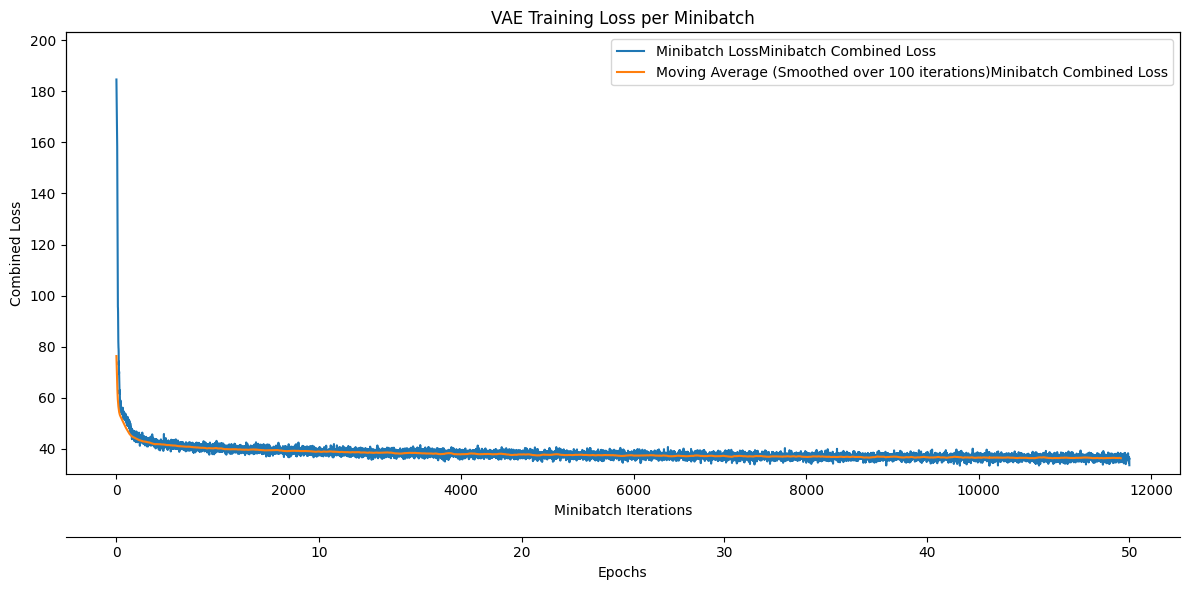

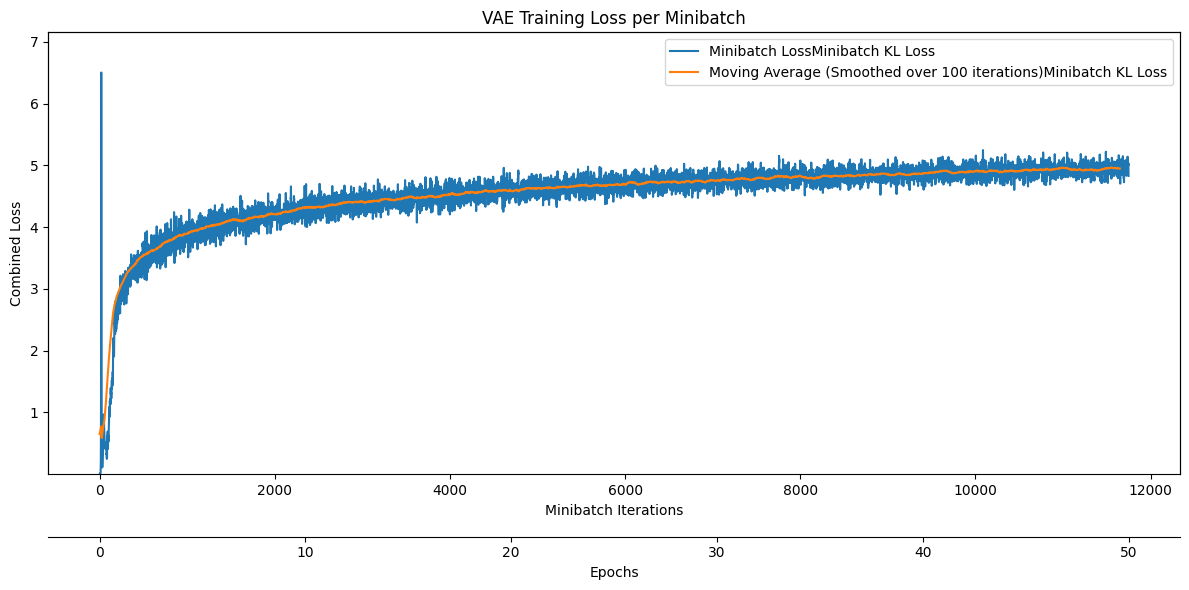

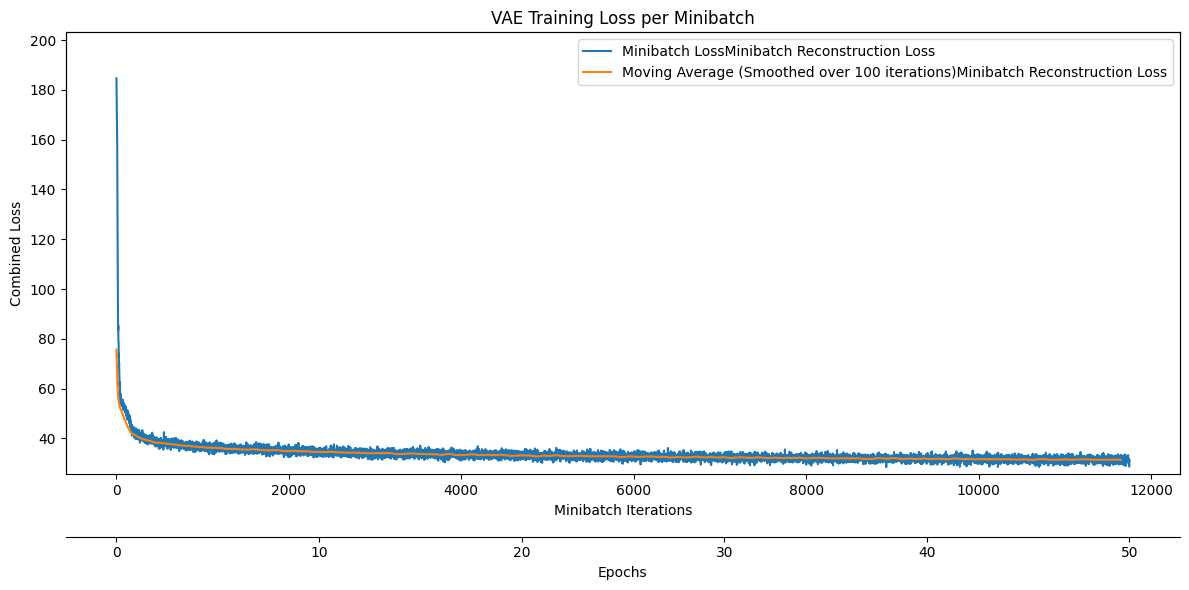

In [110]:
plot_training_data(train_log['train_combined_loss_per_batch'], num_epochs = EPOCHS, custom_label = "Minibatch Combined Loss")   
plot_training_data(train_log['train_kl_loss_per_batch'], num_epochs = EPOCHS, custom_label = "Minibatch KL Loss")
plot_training_data(train_log['train_reconstruction_loss_per_batch'], num_epochs = EPOCHS, custom_label = "Minibatch Reconstruction Loss")

In [111]:
def plot_generated_images(data_loader, model, device = DEVICE,
                          unnormalize = None,
                          figsize=(20, 2.5),
                          n_images=15,
                          model_type = "Autoencoder"):
    fig, axes = plt.subplots(nrows = 2, ncols = n_images, 
                             sharex = True, sharey = True,
                             figsize = figsize)
    for batch_idx, (features, _) in enumerate(data_loader):
        features = features.to(device)
        color_channels = features.shape[1]
        image_height = features.shape[2]
        image_width = features.shape[3]

        with torch.no_grad():
            if model_type == "Autoencoder":
                generated = model(features)[:n_images]
            elif model_type == "VAE":
                encoded, decoded, z_mean, z_log_var = model(features)[:n_images]
            else:
                raise ValueError("model_type must be either 'Autoencoder' or 'VAE'")
        orig_images = features[:n_images].cpu()
        generated = decoded.cpu()
        print(f"{generated.shape}")
        axes[0,0].set_title("Original")
        axes[1,0].set_title("Generated")
        for i in range(n_images):
            ax1 = axes[0, i]
            ax2 = axes[1, i]
            ax1.imshow(orig_images[i].cpu().squeeze(), cmap = "gray")
            
            ax1.axis("off")
            ax2.imshow(generated[i].squeeze(), cmap = "gray")
            
            
        break

torch.Size([256, 1, 28, 28])


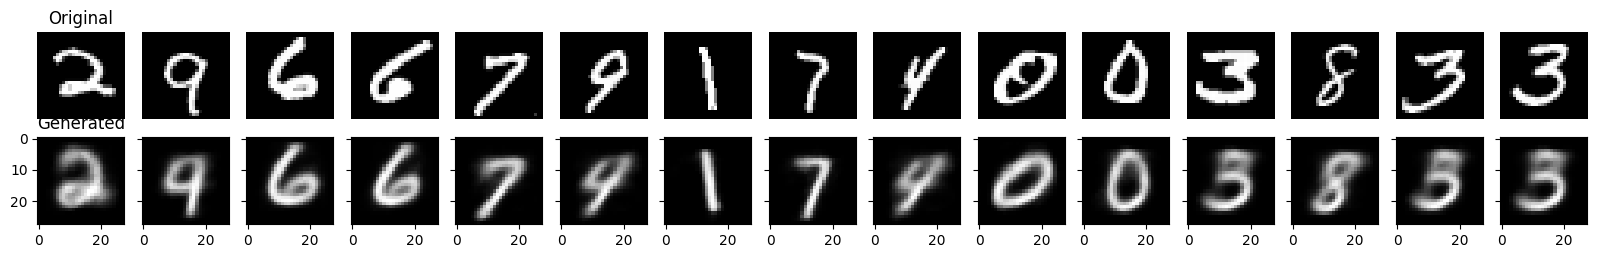

In [112]:
plot_generated_images(train_loader, model=model, device = DEVICE, model_type = "VAE")

In [113]:
import matplotlib.colors as mcolors

In [114]:
def plot_latent_space_with_labels(num_classes, data_loader, encoding_fn, device):
    d = {i:[] for i in range(num_classes)}

    with torch.no_grad():
        for i, (features, targets) in enumerate(data_loader):

            features = features.to(device)
            targets = targets.to(device)
            
            embedding = encoding_fn(features)

            for i in range(num_classes):
                if i in targets:
                    mask = targets == i
                    d[i].append(embedding[mask].to('cpu').numpy())

    colors = list(mcolors.TABLEAU_COLORS.items())
    for i in range(num_classes):
        d[i] = np.concatenate(d[i])
        plt.scatter(
            d[i][:, 0], d[i][:, 1],
            color=colors[i][1],
            label=f'{i}',
            alpha=0.5)

    plt.legend()

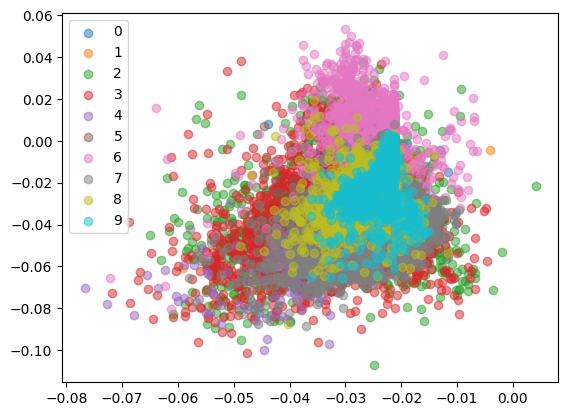

In [115]:
plot_latent_space_with_labels(num_classes=10, data_loader = train_loader, 
                              encoding_fn = model.encoder, device = DEVICE)

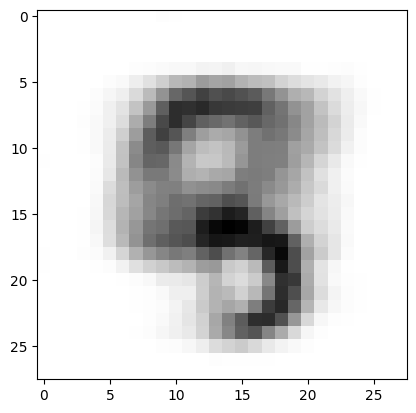

In [122]:
with torch.no_grad():
    new_image = model.decoder(torch.tensor([-1.0, 0.6]).to(DEVICE))
    new_image.squeeze_(0)
    new_image.squeeze_(0)
plt.imshow(new_image.to('cpu').numpy(), cmap='binary')
plt.show()

In [123]:
def plot_images_sampled_from_vae(model, device, latent_size, unnormalizer=None, num_images=10):

    with torch.no_grad():

        ##########################
        ### RANDOM SAMPLE
        ##########################    

        rand_features = torch.randn(num_images, latent_size).to(device)
        new_images = model.decoder(rand_features)
        color_channels = new_images.shape[1]
        image_height = new_images.shape[2]
        image_width = new_images.shape[3]

        ##########################
        ### VISUALIZATION
        ##########################

        image_width = 28

        fig, axes = plt.subplots(nrows=1, ncols=num_images, figsize=(10, 2.5), sharey=True)
        decoded_images = new_images[:num_images]

        for ax, img in zip(axes, decoded_images):
            curr_img = img.detach().to(torch.device('cpu'))        
            if unnormalizer is not None:
                curr_img = unnormalizer(curr_img)

            if color_channels > 1:
                curr_img = np.transpose(curr_img, (1, 2, 0))
                ax.imshow(curr_img)
            else:
                ax.imshow(curr_img.view((image_height, image_width)), cmap='binary') 
              

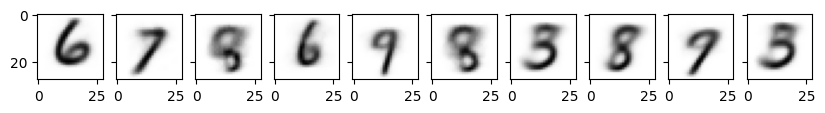

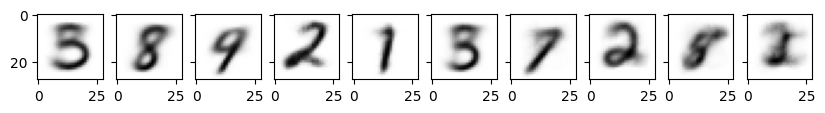

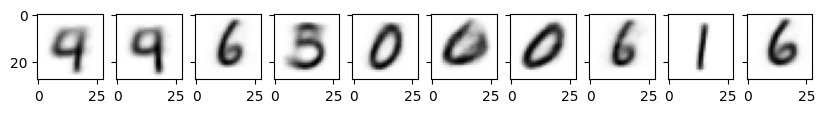

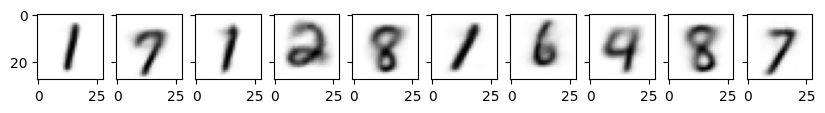

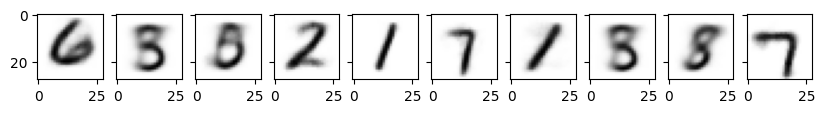

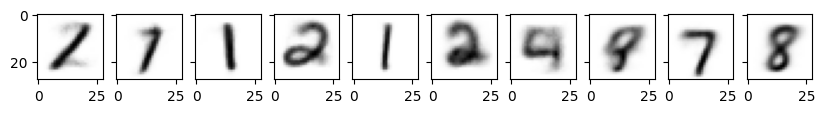

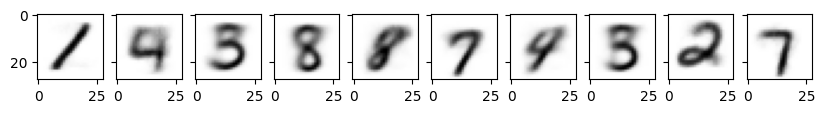

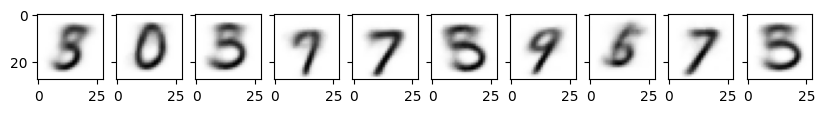

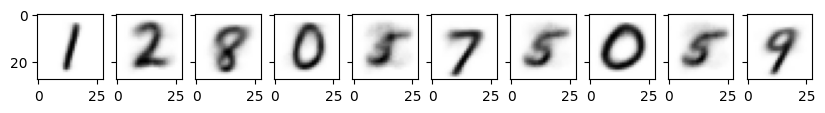

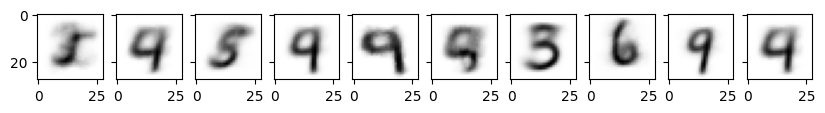

In [124]:
for i in range(10):
    plot_images_sampled_from_vae(model=model, device=DEVICE, latent_size=2)
    plt.show()